In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df1 = pd.read_csv('table1_clear.csv', encoding='big5')
df2 = pd.read_csv('table2_clear.csv', encoding='big5')
df5 = pd.read_csv('table5_clear.csv', encoding='big5')
df6 = pd.read_csv('table6_clear.csv', encoding='big5')
df10 = pd.read_csv('table10_clear.csv', encoding='big5')
df14 = pd.read_csv('table14_clear.csv', encoding='big5')

In [4]:
df1.shape, df2.shape, df5.shape, df6.shape, df10.shape, df14.shape

((88938, 6), (88938, 11), (7979, 9), (37699, 31), (88938, 9), (27968, 86))

In [5]:
data = pd.merge(df14, df1, on='ACCOUNTNO', how='left')
print(data.shape)
data = pd.merge(data, df2, on='ACCOUNTNO', how='left')
print(data.shape)
data = pd.merge(data, df10, on='ACCOUNTNO', how='left')
print(data.shape)
data = pd.merge(data, df6, on='ACCOUNTNO', how='left')
print(data.shape)
data = pd.merge(data, df5, on='ACCOUNTNO', how='left')
print(data.shape)

(27968, 91)
(27968, 101)
(27968, 109)
(27968, 139)
(27968, 147)


In [6]:
data.head()

,ACCOUNTNO,Acyclovir,Amikacin,Amoxicillin,Amoxicillin/Clavulanic acid,Amphotericin B,Amphotericin B/liposome,Ampicillin,Ampicillin/Sulbactam,Azithromycin,Baloxavir marboxil,Cefadroxil,Cefazolin,Cefepime,Cefixime,Cefoperazone/sulbactam,Cefotaxime,Cefoxitin,Ceftazidime,Ceftazidime/Avibactam,Ceftizoxime,Ceftriaxone,Cefuroxime,Cephalexin,Ciprofloxacin,Clarithromycin,Clindamycin,Dicloxacillin,Doripenem,Doxycycline,Ertapenem,Erythromycin,Ethambutol,Famciclovir,Fenticonazole,Flomoxef,Fluconazole,Flucytosine,Fosfomycin,Ganciclovir,Gentamicin,Griseofulvin,Imipenem/Cilastatin,Isoniazid,Itraconazole,Lamivudine/Dolutegravir,Levofloxacin,Linezolid,Meropenem,Metronidazole,Micafungin,Minocycline,Moxifloxacin,Nemonoxacin,Nystatin,Oseltamivir,Oxacillin,Penicillin,Peramivir,Pipemidic acid,Piperacillin/Tazobactam,Pyrazinamide,Rifampin,Rifampin/Isoniazid/Ethambutol,Sulfamethoxazole/Trimethoprim,Teicoplanin,Telbivudine,Tenofovir,Tenofovir alafenamide,Terbinafine,Tetracycline,Valaciclovir,Vancomycin,Zanamivir,abacavir/lamivudine/dolutegravir,ifampin/Isoniazid,tenofovir/emtricitabine,tenofovir/emtricitabine/bictegravir,tenofovir/emtricitabine/rilpivirine,INFECTIONSITE1,INFECTIONSITE2,INFECTIONSITE3,INFECTIONSITE4,INFECTIONSITE5,INFECTIONSITE9,OTHERINFECTIONSITE_flag,ROOMNO,AGE,SEX,StayTime_hours,INTIME,ISSEPSIS0,VITALSIGNSBT,VITALSIGNSPR,VITALSIGNSRR,VITALSIGNSSPO2,VITALSIGNSDBP,VITALSIGNSGCS,MAP,FEVER,INJURELEVEL,DM,CARDIOVASCULAR,RESPIRATORY,CNS,CANCER,LIVER,KIDNEY,AUTOIMMUNE,Hb,WBC,RBC,Ht,PLT,Lymphocyte,Neutrophil Seg.,Absolute Neutrophil count,Na,K,Creatinine,GPT,CRP,HST,Leukocyte level,Nitrite level,Bacteria level,Microscopic RBC level,Microscopic WBC level,PH,Influenza Virus A level,T.Bilirubin,PT,INR,APTT,PCO2,HCO3,BE(ecf),O2 SAT,FIRST_ORDERTIME,CHECKITEM28A,CHECKITEM27,CHECKITEM27SCORE,CHECKITEM28SCORE,CHECKITEM29SCORE,CHECKITEM30SCORE,CHECKITEM31SCORE,CHECKITEM32SCORE
0,I11300000002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0,0,0,A,65.0,M,0.261944,2024-01-01 00:47:17,N,38.2,106.0,20.0,95.0,93.0,15.0,113.0,Y,3.0,N,Y,Y,Y,N,Y,Y,Y,12.5,11.86,4.05,34.1,178.0,6.1,86.4,10247.0,137.0,3.3,1.20,50.0,14.768,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:55:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,I11300000003,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,C,48.0,F,0.460833,2024-01-01 00:50:21,N,36.4,88.0,20.0,NaN,85.0,15.0,105.0,Y,4.0,N,N,N,N,N,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,I11300000008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,A,19.0,F,2.628056,2024-01-01 01:17:19,N,37.6,120.0,18.0,NaN,62.0,15.0,73.0,Y,3.0,N,N,N,N,N,N,N,N,11.4,7.32,5.46,34.6,194.0,19.6,68.6,5234.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,3.0,1.0,2.0,5.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,I11300000011,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [7]:
print(data.nunique())

ACCOUNTNO                      27968
Acyclovir                          2
Amikacin                           2
Amoxicillin                        2
Amoxicillin/Clavulanic acid        2
                               ...  
CHECKITEM28SCORE                   5
CHECKITEM29SCORE                   5
CHECKITEM30SCORE                   4
CHECKITEM31SCORE                   5
CHECKITEM32SCORE                   5
Length: 147, dtype: int64


In [8]:
data.columns

Index(['ACCOUNTNO', 'Acyclovir', 'Amikacin', 'Amoxicillin',
       'Amoxicillin/Clavulanic acid', 'Amphotericin B',
       'Amphotericin B/liposome', 'Ampicillin', 'Ampicillin/Sulbactam',
       'Azithromycin',
       ...
       'O2 SAT', 'FIRST_ORDERTIME', 'CHECKITEM28A', 'CHECKITEM27',
       'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE',
       'CHECKITEM30SCORE', 'CHECKITEM31SCORE', 'CHECKITEM32SCORE'],
      dtype='object', length=147)

In [9]:
data # target: Acyclovir ~ tenofovir/emtricitabine/rilpivirine

,ACCOUNTNO,Acyclovir,Amikacin,Amoxicillin,Amoxicillin/Clavulanic acid,Amphotericin B,Amphotericin B/liposome,Ampicillin,Ampicillin/Sulbactam,Azithromycin,Baloxavir marboxil,Cefadroxil,Cefazolin,Cefepime,Cefixime,Cefoperazone/sulbactam,Cefotaxime,Cefoxitin,Ceftazidime,Ceftazidime/Avibactam,Ceftizoxime,Ceftriaxone,Cefuroxime,Cephalexin,Ciprofloxacin,Clarithromycin,Clindamycin,Dicloxacillin,Doripenem,Doxycycline,Ertapenem,Erythromycin,Ethambutol,Famciclovir,Fenticonazole,Flomoxef,Fluconazole,Flucytosine,Fosfomycin,Ganciclovir,Gentamicin,Griseofulvin,Imipenem/Cilastatin,Isoniazid,Itraconazole,Lamivudine/Dolutegravir,Levofloxacin,Linezolid,Meropenem,Metronidazole,Micafungin,Minocycline,Moxifloxacin,Nemonoxacin,Nystatin,Oseltamivir,Oxacillin,Penicillin,Peramivir,Pipemidic acid,Piperacillin/Tazobactam,Pyrazinamide,Rifampin,Rifampin/Isoniazid/Ethambutol,Sulfamethoxazole/Trimethoprim,Teicoplanin,Telbivudine,Tenofovir,Tenofovir alafenamide,Terbinafine,Tetracycline,Valaciclovir,Vancomycin,Zanamivir,abacavir/lamivudine/dolutegravir,ifampin/Isoniazid,tenofovir/emtricitabine,tenofovir/emtricitabine/bictegravir,tenofovir/emtricitabine/rilpivirine,INFECTIONSITE1,INFECTIONSITE2,INFECTIONSITE3,INFECTIONSITE4,INFECTIONSITE5,INFECTIONSITE9,OTHERINFECTIONSITE_flag,ROOMNO,AGE,SEX,StayTime_hours,INTIME,ISSEPSIS0,VITALSIGNSBT,VITALSIGNSPR,VITALSIGNSRR,VITALSIGNSSPO2,VITALSIGNSDBP,VITALSIGNSGCS,MAP,FEVER,INJURELEVEL,DM,CARDIOVASCULAR,RESPIRATORY,CNS,CANCER,LIVER,KIDNEY,AUTOIMMUNE,Hb,WBC,RBC,Ht,PLT,Lymphocyte,Neutrophil Seg.,Absolute Neutrophil count,Na,K,Creatinine,GPT,CRP,HST,Leukocyte level,Nitrite level,Bacteria level,Microscopic RBC level,Microscopic WBC level,PH,Influenza Virus A level,T.Bilirubin,PT,INR,APTT,PCO2,HCO3,BE(ecf),O2 SAT,FIRST_ORDERTIME,CHECKITEM28A,CHECKITEM27,CHECKITEM27SCORE,CHECKITEM28SCORE,CHECKITEM29SCORE,CHECKITEM30SCORE,CHECKITEM31SCORE,CHECKITEM32SCORE
0,I11300000002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0,0,0,A,65.0,M,0.261944,2024-01-01 00:47:17,N,38.2,106.0,20.0,95.0,93.0,15.0,113.0,Y,3.0,N,Y,Y,Y,N,Y,Y,Y,12.5,11.86,4.05,34.1,178.0,6.1,86.4,10247.0,137.0,3.3,1.20,50.0,14.768,16.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:55:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,I11300000003,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,C,48.0,F,0.460833,2024-01-01 00:50:21,N,36.4,88.0,20.0,NaN,85.0,15.0,105.0,Y,4.0,N,N,N,N,N,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,I11300000008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,A,19.0,F,2.628056,2024-01-01 01:17:19,N,37.6,120.0,18.0,NaN,62.0,15.0,73.0,Y,3.0,N,N,N,N,N,N,N,N,11.4,7.32,5.46,34.6,194.0,19.6,68.6,5234.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,3.0,1.0,2.0,5.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,I11300000011,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

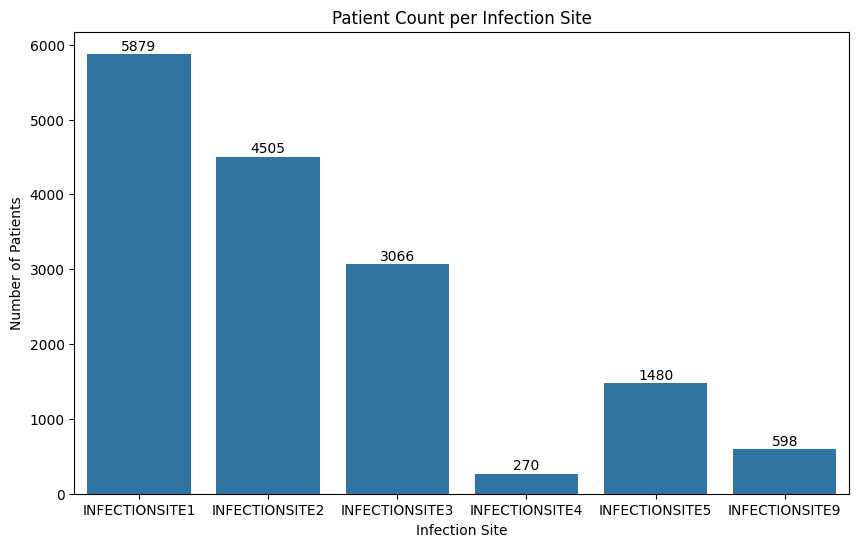

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = data
infection_sites = [
    'INFECTIONSITE1','INFECTIONSITE2','INFECTIONSITE3',
    'INFECTIONSITE4','INFECTIONSITE5','INFECTIONSITE9'
]

site_counts = []

for col in infection_sites:
    count = (df[col] > 0).sum()
    site_counts.append(count)

site_counts = pd.DataFrame({
    "Infection_Site": infection_sites,
    "Patient_Count": site_counts
})

plt.figure(figsize=(10,6))
sns.barplot(data=site_counts, x="Infection_Site", y="Patient_Count")

for i,v in enumerate(site_counts["Patient_Count"]):
    plt.text(i, v+50, str(v), ha='center')

plt.title("Patient Count per Infection Site")
plt.ylabel("Number of Patients")
plt.xlabel("Infection Site")

plt.show()

In [11]:
data.to_csv('anti_total.csv', index=False)

In [12]:
select_cols = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

X = data.iloc[:, select_cols + 1:]

In [13]:
X.columns

Index(['INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3', 'INFECTIONSITE4',
       'INFECTIONSITE5', 'INFECTIONSITE9', 'OTHERINFECTIONSITE_flag', 'ROOMNO',
       'AGE', 'SEX', 'StayTime_hours', 'INTIME', 'ISSEPSIS0', 'VITALSIGNSBT',
       'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP',
       'VITALSIGNSGCS', 'MAP', 'FEVER', 'INJURELEVEL', 'DM', 'CARDIOVASCULAR',
       'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE', 'Hb',
       'WBC', 'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.',
       'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP',
       'HST', 'Leukocyte level', 'Nitrite level', 'Bacteria level',
       'Microscopic RBC level', 'Microscopic WBC level', 'PH',
       'Influenza Virus A level', 'T.Bilirubin', 'PT', 'INR', 'APTT', 'PCO2',
       'HCO3', 'BE(ecf)', 'O2 SAT', 'FIRST_ORDERTIME', 'CHECKITEM28A',
       'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE',
       'CHECKITEM29SCORE', 'CHECKITEM30SCORE', '

In [14]:
X

,INFECTIONSITE1,INFECTIONSITE2,INFECTIONSITE3,INFECTIONSITE4,INFECTIONSITE5,INFECTIONSITE9,OTHERINFECTIONSITE_flag,ROOMNO,AGE,SEX,StayTime_hours,INTIME,ISSEPSIS0,VITALSIGNSBT,VITALSIGNSPR,VITALSIGNSRR,VITALSIGNSSPO2,VITALSIGNSDBP,VITALSIGNSGCS,MAP,FEVER,INJURELEVEL,DM,CARDIOVASCULAR,RESPIRATORY,CNS,CANCER,LIVER,KIDNEY,AUTOIMMUNE,Hb,WBC,RBC,Ht,PLT,Lymphocyte,Neutrophil Seg.,Absolute Neutrophil count,Na,K,Creatinine,GPT,CRP,HST,Leukocyte level,Nitrite level,Bacteria level,Microscopic RBC level,Microscopic WBC level,PH,Influenza Virus A level,T.Bilirubin,PT,INR,APTT,PCO2,HCO3,BE(ecf),O2 SAT,FIRST_ORDERTIME,CHECKITEM28A,CHECKITEM27,CHECKITEM27SCORE,CHECKITEM28SCORE,CHECKITEM29SCORE,CHECKITEM30SCORE,CHECKITEM31SCORE,CHECKITEM32SCORE
0,1,0,0,0,0,0,0,A,65.0,M,0.261944,2024-01-01 00:47:17,N,38.2,106.0,20.0,95.0,93.0,15.0,113.0,Y,3.0,N,Y,Y,Y,N,Y,Y,Y,12.5,11.86,4.05,34.1,178.0,6.1,86.4,10247.0,137.0,3.3,1.20,50.0,14.768,16.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:55:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,0,0,0,0,0,C,48.0,F,0.460833,2024-01-01 00:50:21,N,36.4,88.0,20.0,NaN,85.0,15.0,105.0,Y,4.0,N,N,N,N,N,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,0,0,0,0,0,0,A,19.0,F,2.628056,2024-01-01 01:17:19,N,37.6,120.0,18.0,NaN,62.0,15.0,73.0,Y,3.0,N,N,N,N,N,N,N,N,11.4,7.32,5.46,34.6,194.0,19.6,68.6,5234.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,3.0,1.0,2.0,5.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0,0,0,0,0,0,A,16.0,M,3.546944,2024-01-01 01:25:11,N,36.3,118.0,18.0,NaN,64.0,15.0,77.0,Y,3.0,N,N,Y,N,N,Y,Y,Y,17.4,16.01,6.08,48.2,300.0,8.1,84.4,13512.0,136.0,3.6,0.78,19.0,0.929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:42:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0,0,0,0,0,0,A,22.0,F,2.638056,2024-01-01 03:03:43,N,36.9,103.0,18.0,NaN,61.0,15.0,74.0,Y,3.0,N,N,N,N,N,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27963,1,0,0,0,0,0,0,A,45.0,M,NaN,2025-12-31 15:26:22,N,35.6,112.0,22.0,100.0,90.0,15.0,104.0,Y,3.0,N,N,N,N,N,N,N,N,14.5,7.49,5.12,44.9,209.0,15.2,78.5,5880.0,132.0,4.2,1.21,47.0,1.622,44.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,28.0,16.4,-8.6,96.4,2025-12-31 15:44:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27964,0,1,0,0,0,0,0,A,82.0,M,NaN,2025-12-31 15:37:15,N,36.0,87.0,20.0,98.0,58.0,15.0,74.0,Y,3.0,N,Y,Y,Y,N,Y,Y,Y,10.9,15.08,3.52,30.5,232.0,3.3,87.5,13451.0,148.0,7.6,19.96,7.0,3.577,97.51,1.0,0.0,3.0,2.0,2.0,2.5,NaN,0.3,11.6,1.01,29.2,31.5,18.6,-6.3,97.0,2025-12-31 15:57:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27965,0,1,0,0,0,0,0,A,68.0,M,NaN,2025-12-31 16:39:13,N,36.4,82.0,28.0,96.0,100.0,15.0,121.0,Y,3.0,N,Y,Y,Y,N,Y,Y,Y,11.2,8.41,5.20,34.9,159.0,10.5,83.1,7000.0,139.0,4.7,8.33,11.0,1.365,77.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-31 17:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27966,1,0,0,0,0,0,0,A,71.0,M,NaN,2025-12-31 21:03:32,N,35.8,111.0,26.0,100.0,119.0,15.0,146.0,Y,2.0,Y,Y,Y,Y,N,Y,N,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
Y = data.iloc[:, :select_cols + 1].drop(columns='ACCOUNTNO')

In [16]:
Y.columns, Y.shape

(Index(['Acyclovir', 'Amikacin', 'Amoxicillin', 'Amoxicillin/Clavulanic acid',
        'Amphotericin B', 'Amphotericin B/liposome', 'Ampicillin',
        'Ampicillin/Sulbactam', 'Azithromycin', 'Baloxavir marboxil',
        'Cefadroxil', 'Cefazolin', 'Cefepime', 'Cefixime',
        'Cefoperazone/sulbactam', 'Cefotaxime', 'Cefoxitin', 'Ceftazidime',
        'Ceftazidime/Avibactam', 'Ceftizoxime', 'Ceftriaxone', 'Cefuroxime',
        'Cephalexin', 'Ciprofloxacin', 'Clarithromycin', 'Clindamycin',
        'Dicloxacillin', 'Doripenem', 'Doxycycline', 'Ertapenem',
        'Erythromycin', 'Ethambutol', 'Famciclovir', 'Fenticonazole',
        'Flomoxef', 'Fluconazole', 'Flucytosine', 'Fosfomycin', 'Ganciclovir',
        'Gentamicin', 'Griseofulvin', 'Imipenem/Cilastatin', 'Isoniazid',
        'Itraconazole', 'Lamivudine/Dolutegravir', 'Levofloxacin', 'Linezolid',
        'Meropenem', 'Metronidazole', 'Micafungin', 'Minocycline',
        'Moxifloxacin', 'Nemonoxacin', 'Nystatin', 'Oseltamivir'

In [17]:
features_with_na = [features for features in X.columns if X[features].isnull().sum() > 1]

for feature in features_with_na:
    print(feature, (X[feature].isnull().sum()/len(X[feature]) *100).round(1), '% missing values')


StayTime_hours 55.3 % missing values
VITALSIGNSBT 1.1 % missing values
VITALSIGNSPR 4.0 % missing values
VITALSIGNSRR 3.9 % missing values
VITALSIGNSSPO2 25.1 % missing values
VITALSIGNSDBP 11.2 % missing values
VITALSIGNSGCS 1.5 % missing values
MAP 11.2 % missing values
Hb 40.5 % missing values
WBC 41.0 % missing values
RBC 41.2 % missing values
Ht 40.6 % missing values
PLT 41.0 % missing values
Lymphocyte 41.8 % missing values
Neutrophil Seg. 41.8 % missing values
Absolute Neutrophil count 41.9 % missing values
Na 43.3 % missing values
K 43.4 % missing values
Creatinine 43.3 % missing values
GPT 44.9 % missing values
CRP 54.0 % missing values
HST 82.4 % missing values
Leukocyte level 72.8 % missing values
Nitrite level 72.8 % missing values
Bacteria level 72.8 % missing values
Microscopic RBC level 72.8 % missing values
Microscopic WBC level 72.8 % missing values
PH 72.8 % missing values
Influenza Virus A level 87.5 % missing values
T.Bilirubin 84.7 % missing values
PT 81.0 % missin